<a href="https://colab.research.google.com/github/shreyasshikhare11/Physics-Informed-Neural-Network/blob/main/Physics_Informed_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://arxiv.org/abs/1711.10561

https://arxiv.org/abs/1711.10566

Burger's equation

epoch      1 | loss 2.3448e-01
epoch    500 | loss 4.8710e-02
epoch   1000 | loss 3.0969e-02
epoch   1500 | loss 2.7837e-02
epoch   2000 | loss 1.4608e-02
epoch   2500 | loss 7.0423e-03


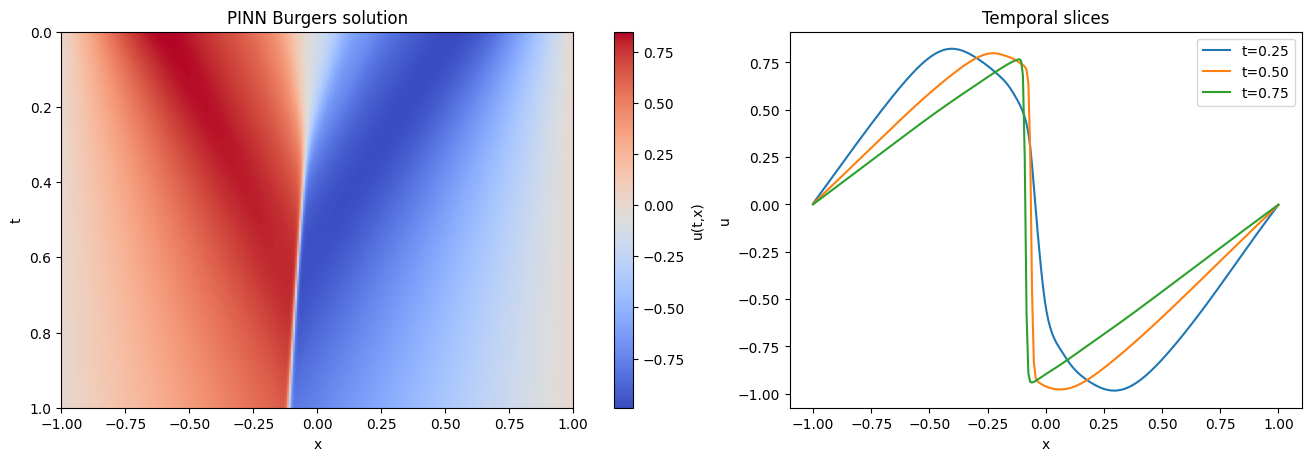

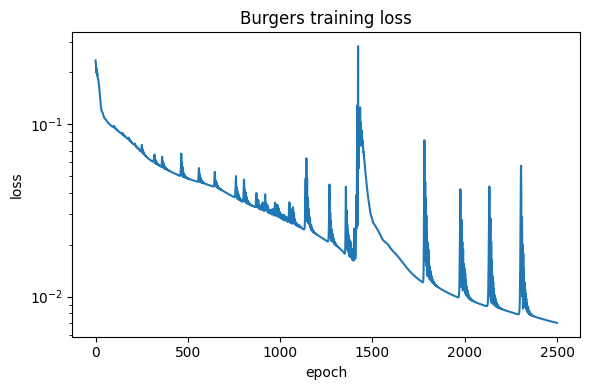

Saved figures to /content/outputs/pinn


In [ ]:
from __future__ import annotations

import argparse
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn


torch.set_default_dtype(torch.float64)


class MLP(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, width: int = 64, depth: int = 5):
        super().__init__()
        layers = [nn.Linear(in_dim, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, out_dim)]
        self.net = nn.Sequential(*layers)
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)


def grad(y, x, dim):
    return torch.autograd.grad(y, x, torch.ones_like(y), create_graph=True,
                               retain_graph=True)[0][:, dim:dim + 1]


def mse(x):
    return torch.mean(x ** 2)


def train(model, loss_fn, epochs, lr=1e-3, print_every=500):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(1, epochs + 1):
        opt.zero_grad()
        loss = loss_fn()
        loss.backward()
        opt.step()
        history.append(float(loss.detach()))
        if epoch == 1 or epoch % print_every == 0:
            print(f"epoch {epoch:6d} | loss {history[-1]:.4e}")
    return history


def burgers(outdir, epochs):
    # u_t + u u_x - nu u_xx = 0, x in [-1,1], t in [0,1].
    nu = 0.01 / math.pi
    rng = np.random.default_rng(7)
    n_data, n_f = 256, 5000
    x0 = rng.uniform(-1, 1, (n_data // 2, 1))
    t0 = np.zeros_like(x0)
    y0 = -np.sin(math.pi * x0)
    tb = rng.uniform(0, 1, (n_data // 4, 1))
    xb = np.vstack([-np.ones_like(tb), np.ones_like(tb)])
    tb = np.vstack([tb, tb])
    yb = np.zeros_like(xb)
    xu = np.vstack([np.hstack([t0, x0]), np.hstack([tb, xb])])
    yu = np.vstack([y0, yb])
    tf = rng.uniform(0, 1, (n_f, 1))
    xf = rng.uniform(-1, 1, (n_f, 1))

    X_u = torch.tensor(xu, requires_grad=True)
    Y_u = torch.tensor(yu)
    X_f = torch.tensor(np.hstack([tf, xf]), requires_grad=True)
    model = MLP(2, 1, width=64, depth=5)

    def loss_fn():
        pred_u = model(X_u)
        u = model(X_f)
        u_t = grad(u, X_f, 0)
        u_x = grad(u, X_f, 1)
        u_xx = grad(u_x, X_f, 1)
        residual = u_t + u * u_x - nu * u_xx
        return mse(pred_u - Y_u) + mse(residual)

    history = train(model, loss_fn, epochs)
    t_plot = np.linspace(0, 1, 161)
    x_plot = np.linspace(-1, 1, 256)
    tt, xx = np.meshgrid(t_plot, x_plot, indexing="ij")
    with torch.no_grad():
        pred = model(torch.tensor(np.c_[tt.ravel(), xx.ravel()])).numpy().reshape(tt.shape)
    outdir.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
    im = ax[0].imshow(pred, extent=[-1, 1, 1, 0], aspect="auto", cmap="coolwarm")
    ax[0].set(xlabel="x", ylabel="t", title="PINN Burgers solution")
    fig.colorbar(im, ax=ax[0], label="u(t,x)")
    for t in [0.25, 0.50, 0.75]:
        k = int(t * (len(t_plot) - 1))
        ax[1].plot(x_plot, pred[k], label=f"t={t:.2f}")
    ax[1].set(xlabel="x", ylabel="u", title="Temporal slices")
    ax[1].legend()
    fig.savefig(outdir / "burgers_pinn.png", dpi=180)
    plt.show()
    plt.close(fig)
    plot_history(history, outdir / "burgers_loss.png", "Burgers training loss")


def nls(outdir, epochs):
    # i h_t + 0.5 h_xx + |h|^2 h = 0, h=u+i v.
    rng = np.random.default_rng(8)
    n0, nb, nf = 256, 256, 6000
    x0 = rng.uniform(-5, 5, (n0, 1))
    X0 = np.c_[np.zeros_like(x0), x0]
    H0 = np.c_[2 / np.cosh(x0), np.zeros_like(x0)]
    tb = rng.uniform(0, math.pi / 2, (nb, 1))
    Xl = np.c_[tb, -5 * np.ones_like(tb)]
    Xr = np.c_[tb, 5 * np.ones_like(tb)]
    tf = rng.uniform(0, math.pi / 2, (nf, 1))
    xf = rng.uniform(-5, 5, (nf, 1))
    Xf = np.c_[tf, xf]
    T0, TL, TR, TF = [torch.tensor(z, requires_grad=True) for z in (X0, Xl, Xr, Xf)]
    H0t = torch.tensor(H0)
    model = MLP(2, 2, width=64, depth=5)

    def residual(X):
        h = model(X)
        u, v = h[:, 0:1], h[:, 1:2]
        u_t, v_t = grad(u, X, 0), grad(v, X, 0)
        u_x, v_x = grad(u, X, 1), grad(v, X, 1)
        u_xx, v_xx = grad(u_x, X, 1), grad(v_x, X, 1)
        amp2 = u ** 2 + v ** 2
        # Real and imaginary parts of i h_t + .5 h_xx + |h|^2 h.
        r_u = -v_t + 0.5 * u_xx + amp2 * u
        r_v = u_t + 0.5 * v_xx + amp2 * v
        return r_u, r_v

    def loss_fn():
        loss0 = mse(model(T0) - H0t)
        hl, hr = model(TL), model(TR)
        ulx, vlx = grad(hl[:, 0:1], TL, 1), grad(hl[:, 1:2], TL, 1)
        urx, vrx = grad(hr[:, 0:1], TR, 1), grad(hr[:, 1:2], TR, 1)
        lossb = mse(hl - hr) + mse(ulx - urx) + mse(vlx - vrx)
        ru, rv = residual(TF)
        return loss0 + lossb + mse(ru) + mse(rv)

    history = train(model, loss_fn, epochs)
    t_plot = np.linspace(0, math.pi / 2, 121)
    x_plot = np.linspace(-5, 5, 256)
    tt, xx = np.meshgrid(t_plot, x_plot, indexing="ij")
    with torch.no_grad():
        h = model(torch.tensor(np.c_[tt.ravel(), xx.ravel()])).numpy().reshape(*tt.shape, 2)
    amp = np.sqrt(h[..., 0] ** 2 + h[..., 1] ** 2)
    outdir.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
    im = ax[0].imshow(amp, extent=[-5, 5, math.pi / 2, 0], aspect="auto", cmap="viridis")
    ax[0].set(xlabel="x", ylabel="t", title="PINN NLS amplitude |h|")
    fig.colorbar(im, ax=ax[0], label="|h|")
    for t in [0, math.pi / 4, math.pi / 2]:
        k = int(t / (math.pi / 2) * (len(t_plot) - 1))
        ax[1].plot(x_plot, amp[k], label=f"t={t:.2f}")
    ax[1].set(xlabel="x", ylabel="|h|", title="Amplitude slices")
    ax[1].legend()
    fig.savefig(outdir / "nls_pinn.png", dpi=180)
    plt.show()
    plt.close(fig)
    plot_history(history, outdir / "nls_loss.png", "NLS training loss")


def plot_history(history, path, title):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.semilogy(history)
    ax.set(xlabel="epoch", ylabel="loss", title=title)
    fig.tight_layout()
    fig.savefig(path, dpi=180)
    plt.show()
    plt.close(fig)


def main():
    p = argparse.ArgumentParser()
    p.add_argument("--problem", choices=["burgers", "nls"], default="burgers")
    p.add_argument("--epochs", type=int, default=2500)
    p.add_argument("--outdir", type=Path, default=Path("outputs/pinn"))
    # Fix: Use an empty list to avoid parsing Colab's internal kernel flags
    args = p.parse_args(args=[])
    torch.manual_seed(1)
    if args.problem == "burgers":
        burgers(args.outdir, args.epochs)
    else:
        nls(args.outdir, args.epochs)
    print(f"Saved figures to {args.outdir.resolve()}")


if __name__ == "__main__":
    main()

Schrodinger equation

In [ ]:
"""Physics-informed neural network for the 1-D nonlinear Schrodinger equation.

Paper problem (Raissi, Perdikaris & Karniadakis, 2017):
    i h_t + 0.5 h_xx + |h|^2 h = 0,  x in [-5, 5], t in [0, pi/2]
    h(0, x) = 2 sech(x)
    h(t, -5) = h(t, 5),  h_x(t, -5) = h_x(t, 5)

The PINN output is (u, v), where h=u+i v.  A split-step Fourier solver is
included only as an independent reference for evaluating and plotting the PINN.

Example:
    pip install -r requirements.txt
    python work/nls_pinn.py --epochs 5000
"""

from __future__ import annotations

import argparse
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn


torch.set_default_dtype(torch.float64)


class PINN(nn.Module):
    """Tanh multilayer perceptron with coordinates scaled to [-1, 1]."""

    def __init__(self, width: int = 64, depth: int = 5):
        super().__init__()
        self.register_buffer("lower", torch.tensor([0.0, -5.0]))
        self.register_buffer("upper", torch.tensor([math.pi / 2, 5.0]))
        layers: list[nn.Module] = [nn.Linear(2, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 2)]
        self.net = nn.Sequential(*layers)
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, tx: torch.Tensor) -> torch.Tensor:
        tx = 2.0 * (tx - self.lower) / (self.upper - self.lower) - 1.0
        return self.net(tx)


def derivative(y: torch.Tensor, x: torch.Tensor, axis: int) -> torch.Tensor:
    """Derivative of a scalar network output with respect to t (0) or x (1)."""
    return torch.autograd.grad(
        y, x, grad_outputs=torch.ones_like(y), create_graph=True, retain_graph=True
    )[0][:, axis : axis + 1]


def mean_square(value: torch.Tensor) -> torch.Tensor:
    return torch.mean(value.square())


def nls_residual(model: PINN, tx: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    """Real and imaginary residuals of i*h_t + .5*h_xx + |h|^2*h."""
    uv = model(tx)
    u, v = uv[:, :1], uv[:, 1:]
    u_t, v_t = derivative(u, tx, 0), derivative(v, tx, 0)
    u_x, v_x = derivative(u, tx, 1), derivative(v, tx, 1)
    u_xx, v_xx = derivative(u_x, tx, 1), derivative(v_x, tx, 1)
    amplitude_squared = u.square() + v.square()
    real = -v_t + 0.5 * u_xx + amplitude_squared * u
    imaginary = u_t + 0.5 * v_xx + amplitude_squared * v
    return real, imaginary


def split_step_reference(x: np.ndarray, times: np.ndarray, dt: float = 2.0e-4) -> np.ndarray:
    """Periodic Strang split-step Fourier reference solution at requested times."""
    dx = x[1] - x[0]
    k = 2.0 * np.pi * np.fft.fftfreq(x.size, d=dx)
    h = (2.0 / np.cosh(x)).astype(np.complex128)
    output = np.empty((times.size, x.size), dtype=np.complex128)
    current = 0.0
    for i, target in enumerate(times):
        while current < target - 1.0e-12:
            step = min(dt, target - current)
            h *= np.exp(0.5j * np.abs(h) ** 2 * step)
            h = np.fft.ifft(np.fft.fft(h) * np.exp(-0.5j * k**2 * step))
            h *= np.exp(0.5j * np.abs(h) ** 2 * step)
            current += step
        output[i] = h
    return output


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--epochs", type=int, default=5000)
    parser.add_argument("--width", type=int, default=64)
    parser.add_argument("--depth", type=int, default=5)
    parser.add_argument("--n-initial", type=int, default=256)
    parser.add_argument("--n-boundary", type=int, default=256)
    parser.add_argument("--n-collocation", type=int, default=6000)
    parser.add_argument("--outdir", type=Path, default=Path("outputs/nls_pinn"))
    args = parser.parse_args()

    rng = np.random.default_rng(8)
    torch.manual_seed(8)
    # Initial data h(0,x)=2 sech(x), represented as (real, imaginary) targets.
    x0 = rng.uniform(-5.0, 5.0, (args.n_initial, 1))
    initial_tx = torch.tensor(np.c_[np.zeros_like(x0), x0], requires_grad=True)
    initial_h = torch.tensor(np.c_[2.0 / np.cosh(x0), np.zeros_like(x0)])
    # Matching h and h_x at x=-5 and x=5 establishes periodicity.
    boundary_t = rng.uniform(0.0, math.pi / 2, (args.n_boundary, 1))
    left_tx = torch.tensor(np.c_[boundary_t, -5.0 * np.ones_like(boundary_t)], requires_grad=True)
    right_tx = torch.tensor(np.c_[boundary_t, 5.0 * np.ones_like(boundary_t)], requires_grad=True)
    collocation_tx = torch.tensor(
        np.c_[rng.uniform(0.0, math.pi / 2, (args.n_collocation, 1)),
              rng.uniform(-5.0, 5.0, (args.n_collocation, 1))],
        requires_grad=True,
    )

    model = PINN(args.width, args.depth)
    optimizer = torch.optim.Adam(model.parameters(), lr=1.0e-3)
    history: list[float] = []
    for epoch in range(1, args.epochs + 1):
        optimizer.zero_grad()
        loss_initial = mean_square(model(initial_tx) - initial_h)
        left, right = model(left_tx), model(right_tx)
        left_ux, left_vx = derivative(left[:, :1], left_tx, 1), derivative(left[:, 1:], left_tx, 1)
        right_ux, right_vx = derivative(right[:, :1], right_tx, 1), derivative(right[:, 1:], right_tx, 1)
        loss_periodic = (mean_square(left - right) + mean_square(left_ux - right_ux)
                         + mean_square(left_vx - right_vx))
        real_residual, imaginary_residual = nls_residual(model, collocation_tx)
        loss_physics = mean_square(real_residual) + mean_square(imaginary_residual)
        loss = loss_initial + loss_periodic + loss_physics
        loss.backward()
        optimizer.step()
        history.append(float(loss.detach()))
        if epoch == 1 or epoch % 500 == 0:
            print(f"epoch {epoch:5d} | total={loss.item():.3e} | initial={loss_initial.item():.3e} | physics={loss_physics.item():.3e}")

    args.outdir.mkdir(parents=True, exist_ok=True)
    n_time, n_space = 121, 256
    times = np.linspace(0.0, math.pi / 2, n_time)
    x = np.linspace(-5.0, 5.0, n_space, endpoint=False)
    tt, xx = np.meshgrid(times, x, indexing="ij")
    with torch.no_grad():
        prediction = model(torch.tensor(np.c_[tt.ravel(), xx.ravel()])).numpy().reshape(n_time, n_space, 2)
    h_pinn = prediction[..., 0] + 1j * prediction[..., 1]
    h_reference = split_step_reference(x, times)
    relative_l2 = np.linalg.norm(h_pinn - h_reference) / np.linalg.norm(h_reference)
    print(f"relative L2 error against split-step reference: {relative_l2:.3e}")

    fig, ax = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
    extent = [-5.0, 5.0, math.pi / 2, 0.0]
    reference_image = ax[0, 0].imshow(np.abs(h_reference), extent=extent, aspect="auto", cmap="viridis")
    ax[0, 0].set(title="Reference amplitude |h|", xlabel="x", ylabel="t")
    fig.colorbar(reference_image, ax=ax[0, 0])
    pinn_image = ax[0, 1].imshow(np.abs(h_pinn), extent=extent, aspect="auto", cmap="viridis")
    ax[0, 1].set(title="PINN amplitude |h|", xlabel="x", ylabel="t")
    fig.colorbar(pinn_image, ax=ax[0, 1])
    error_image = ax[1, 0].imshow(np.abs(h_pinn - h_reference), extent=extent, aspect="auto", cmap="magma")
    ax[1, 0].set(title="Absolute complex-field error", xlabel="x", ylabel="t")
    fig.colorbar(error_image, ax=ax[1, 0])
    for time in (0.0, math.pi / 4, math.pi / 2):
        row = int(round(time / (math.pi / 2) * (n_time - 1)))
        ax[1, 1].plot(x, np.abs(h_reference[row]), "--", label=f"reference, t={time:.2f}")
        ax[1, 1].plot(x, np.abs(h_pinn[row]), label=f"PINN, t={time:.2f}")
    ax[1, 1].set(title="Amplitude slices", xlabel="x", ylabel="|h|")
    ax[1, 1].legend(fontsize=8, ncol=2)
    fig.savefig(args.outdir / "nls_solution_comparison.png", dpi=180)
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.semilogy(history)
    ax.set(title="NLS PINN training loss", xlabel="epoch", ylabel="loss")
    fig.tight_layout()
    fig.savefig(args.outdir / "nls_training_loss.png", dpi=180)
    plt.close(fig)
    plt.show()


if __name__ == "__main__":
    main()


Navier Stokes equation

In [ ]:
"""PINN for 2-D incompressible Navier-Stokes using a Taylor-Green vortex.

The network predicts streamfunction psi and pressure p.  Defining
u=psi_y and v=-psi_x makes u_x+v_y=0 identically, as in Raissi et al. Part II.
Sparse velocity observations and PDE residuals recover the flow and viscosity.

    u_t + lambda1 (u u_x + v u_y) = -p_x + lambda2 Delta u
    v_t + lambda1 (u v_x + v v_y) = -p_y + lambda2 Delta v

Run: python work/navier_stokes_pinn.py --epochs 8000
"""

from __future__ import annotations

import argparse
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

torch.set_default_dtype(torch.float64)
NU_TRUE = 0.01


class StreamPressurePINN(nn.Module):
    def __init__(self, width: int = 64, depth: int = 6, learn_coefficients: bool = True):
        super().__init__()
        self.register_buffer("lo", torch.tensor([0.0, 0.0, 0.0]))
        self.register_buffer("hi", torch.tensor([1.0, 2 * math.pi, 2 * math.pi]))
        layers: list[nn.Module] = [nn.Linear(3, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers.append(nn.Linear(width, 2))  # psi, p
        self.net = nn.Sequential(*layers)
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)
        # Positive coefficients parameterized logarithmically: lambda1 and nu.
        self.log_lambda1 = nn.Parameter(torch.tensor(0.0), requires_grad=learn_coefficients)
        self.log_nu = nn.Parameter(torch.tensor(math.log(0.02)), requires_grad=learn_coefficients)

    def forward(self, txy: torch.Tensor) -> torch.Tensor:
        z = 2 * (txy - self.lo) / (self.hi - self.lo) - 1
        return self.net(z)

    @property
    def lambda1(self):
        return self.log_lambda1.exp()

    @property
    def nu(self):
        return self.log_nu.exp()


def d(value, coordinates, axis):
    return torch.autograd.grad(value, coordinates, torch.ones_like(value),
                               create_graph=True, retain_graph=True)[0][:, axis:axis + 1]


def velocity_and_pressure(model, txy):
    psi_p = model(txy)
    psi, p = psi_p[:, :1], psi_p[:, 1:]
    u, v = d(psi, txy, 2), -d(psi, txy, 1)
    return u, v, p


def residual(model, txy):
    u, v, p = velocity_and_pressure(model, txy)
    u_t, v_t = d(u, txy, 0), d(v, txy, 0)
    u_x, u_y, v_x, v_y = d(u, txy, 1), d(u, txy, 2), d(v, txy, 1), d(v, txy, 2)
    lap_u = d(u_x, txy, 1) + d(u_y, txy, 2)
    lap_v = d(v_x, txy, 1) + d(v_y, txy, 2)
    f = u_t + model.lambda1 * (u * u_x + v * u_y) + d(p, txy, 1) - model.nu * lap_u
    g = v_t + model.lambda1 * (u * v_x + v * v_y) + d(p, txy, 2) - model.nu * lap_v
    return f, g


def taylor_green(txy):
    """Exact periodic solution of 2-D Navier-Stokes on [0,2pi]^2."""
    t, x, y = txy[:, :1], txy[:, 1:2], txy[:, 2:]
    u = -torch.cos(x) * torch.sin(y) * torch.exp(-2 * NU_TRUE * t)
    v = torch.sin(x) * torch.cos(y) * torch.exp(-2 * NU_TRUE * t)
    p = -0.25 * (torch.cos(2 * x) + torch.cos(2 * y)) * torch.exp(-4 * NU_TRUE * t)
    return u, v, p


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--epochs", type=int, default=8000)
    parser.add_argument("--n-data", type=int, default=1200)
    parser.add_argument("--n-collocation", type=int, default=6000)
    parser.add_argument("--width", type=int, default=64)
    parser.add_argument("--depth", type=int, default=6)
    parser.add_argument("--fixed-viscosity", action="store_true")
    parser.add_argument("--outdir", type=Path, default=Path("outputs/navier_stokes_pinn"))
    args = parser.parse_args()
    torch.manual_seed(12)
    rng = np.random.default_rng(12)
    data_txy = torch.tensor(np.c_[rng.uniform(0, 1, (args.n_data, 1)),
                                   rng.uniform(0, 2 * math.pi, (args.n_data, 2))], requires_grad=True)
    target_u, target_v, _ = taylor_green(data_txy)
    target_u, target_v = target_u.detach(), target_v.detach()
    collocation = torch.tensor(np.c_[rng.uniform(0, 1, (args.n_collocation, 1)),
                                     rng.uniform(0, 2 * math.pi, (args.n_collocation, 2))], requires_grad=True)
    model = StreamPressurePINN(args.width, args.depth, not args.fixed_viscosity)
    if args.fixed_viscosity:
        with torch.no_grad():
            model.log_nu.copy_(torch.tensor(math.log(NU_TRUE)))
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    history = []
    for epoch in range(1, args.epochs + 1):
        optimizer.zero_grad()
        u, v, _ = velocity_and_pressure(model, data_txy)
        data_loss = torch.mean((u - target_u).square()) + torch.mean((v - target_v).square())
        f, g = residual(model, collocation)
        physics_loss = torch.mean(f.square()) + torch.mean(g.square())
        loss = data_loss + physics_loss
        loss.backward()
        optimizer.step()
        history.append(loss.item())
        if epoch == 1 or epoch % 500 == 0:
            print(f"epoch {epoch:5d} | loss={loss.item():.3e} | lambda1={model.lambda1.item():.5f} | nu={model.nu.item():.5f}")

    args.outdir.mkdir(parents=True, exist_ok=True)
    n = 101
    x = np.linspace(0, 2 * math.pi, n)
    y = np.linspace(0, 2 * math.pi, n)
    xx, yy = np.meshgrid(x, y, indexing="xy")
    t = np.ones_like(xx)  # final-time visual comparison
    # Velocity is a derivative of psi, so input gradients must remain enabled.
    grid = torch.tensor(np.c_[t.ravel(), xx.ravel(), yy.ravel()], requires_grad=True)
    u, v, p = velocity_and_pressure(model, grid)
    _, _, p_exact = taylor_green(grid)
    u, v, p, p_exact = [z.detach().numpy().reshape(n, n) for z in (u, v, p, p_exact)]
    speed = np.sqrt(u**2 + v**2)
    pressure_error = p - p_exact
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
    im = ax[0].contourf(xx, yy, speed, 40, cmap="viridis")
    ax[0].streamplot(x, y, u, v, color="white", density=1.1, linewidth=.6)
    ax[0].set(title="PINN velocity magnitude and streamlines", xlabel="x", ylabel="y")
    fig.colorbar(im, ax=ax[0])
    im = ax[1].contourf(xx, yy, p, 40, cmap="coolwarm")
    ax[1].set(title="Recovered pressure", xlabel="x", ylabel="y")
    fig.colorbar(im, ax=ax[1])
    im = ax[2].contourf(xx, yy, pressure_error, 40, cmap="coolwarm")
    ax[2].set(title="Pressure error", xlabel="x", ylabel="y")
    fig.colorbar(im, ax=ax[2])
    fig.savefig(args.outdir / "navier_stokes_flow.png", dpi=180)
    plt.close(fig)
    plt.show()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.semilogy(history)
    ax.set(title="Navier-Stokes PINN training loss", xlabel="epoch", ylabel="loss")
    fig.tight_layout(); fig.savefig(args.outdir / "navier_stokes_loss.png", dpi=180); plt.close(fig)
    print(f"true nu={NU_TRUE:.5f}; learned nu={model.nu.item():.5f}")


if __name__ == "__main__":
    main()


Korteweg–de Vries equations

In [ ]:
"""PINN for Korteweg-de Vries (KdV) equation with an exact one-soliton check.

    u_t + lambda1*u*u_x + lambda2*u_xxx = 0

Default lambda1=6, lambda2=1 gives u=(c/2) sech^2(sqrt(c)/2*(x-c*t-x0)).
Run: python work/kdv_pinn.py --epochs 6000
"""

from __future__ import annotations

import argparse
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

torch.set_default_dtype(torch.float64)


class KdVPINN(nn.Module):
    def __init__(self, width=64, depth=5):
        super().__init__()
        self.register_buffer("lo", torch.tensor([0.0, -10.0]))
        self.register_buffer("hi", torch.tensor([1.0, 10.0]))
        layers: list[nn.Module] = [nn.Linear(2, width), nn.Tanh()]
        for _ in range(depth - 1): layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
        for layer in self.net:
            if isinstance(layer, nn.Linear): nn.init.xavier_normal_(layer.weight); nn.init.zeros_(layer.bias)

    def forward(self, tx):
        return self.net(2 * (tx - self.lo) / (self.hi - self.lo) - 1)


def d(y, x, axis):
    return torch.autograd.grad(y, x, torch.ones_like(y), create_graph=True, retain_graph=True)[0][:, axis:axis + 1]


def soliton(tx, c=1.0, x0=-4.0):
    z = 0.5 * np.sqrt(c) * (tx[:, 1:2] - c * tx[:, :1] - x0)
    return 0.5 * c / torch.cosh(z).square()


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--epochs", type=int, default=6000)
    parser.add_argument("--n-initial", type=int, default=256)
    parser.add_argument("--n-boundary", type=int, default=128)
    parser.add_argument("--n-collocation", type=int, default=6000)
    parser.add_argument("--outdir", type=Path, default=Path("outputs/kdv_pinn"))
    args = parser.parse_args()
    rng = np.random.default_rng(21); torch.manual_seed(21)
    x0 = rng.uniform(-10, 10, (args.n_initial, 1))
    tx0 = torch.tensor(np.c_[np.zeros_like(x0), x0], requires_grad=True)
    y0 = soliton(tx0).detach()
    tb = rng.uniform(0, 1, (args.n_boundary, 1))
    left = torch.tensor(np.c_[tb, -10 * np.ones_like(tb)], requires_grad=True)
    right = torch.tensor(np.c_[tb, 10 * np.ones_like(tb)], requires_grad=True)
    collocation = torch.tensor(np.c_[rng.uniform(0, 1, (args.n_collocation, 1)), rng.uniform(-10, 10, (args.n_collocation, 1))], requires_grad=True)
    model = KdVPINN(); optimizer = torch.optim.Adam(model.parameters(), lr=1e-3); history=[]
    for epoch in range(1, args.epochs + 1):
        optimizer.zero_grad()
        u0 = model(tx0); u = model(collocation)
        ut, ux = d(u, collocation, 0), d(u, collocation, 1)
        uxxx = d(d(ux, collocation, 1), collocation, 1)
        residual = ut + 6 * u * ux + uxxx
        # Soliton has near-zero tails; equal endpoint values and slopes approximate the far-field BC.
        boundary_loss = (model(left) - model(right)).square().mean() + (d(model(left), left, 1) - d(model(right), right, 1)).square().mean()
        loss = (u0 - y0).square().mean() + residual.square().mean() + boundary_loss
        loss.backward(); optimizer.step(); history.append(loss.item())
        if epoch == 1 or epoch % 500 == 0: print(f"epoch {epoch:5d} | loss={loss.item():.3e}")
    args.outdir.mkdir(parents=True, exist_ok=True)
    times, x = np.linspace(0, 1, 121), np.linspace(-10, 10, 401)
    tt, xx = np.meshgrid(times, x, indexing="ij")
    grid = torch.tensor(np.c_[tt.ravel(), xx.ravel()])
    with torch.no_grad(): pred = model(grid).numpy().reshape(tt.shape); exact = soliton(grid).numpy().reshape(tt.shape)
    rel_l2 = np.linalg.norm(pred-exact)/np.linalg.norm(exact); print(f"relative L2 error: {rel_l2:.3e}")
    fig, ax = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    for a, data, title, cmap in zip(ax, [exact, pred, np.abs(pred-exact)], ["Exact KdV soliton", "PINN KdV solution", "Absolute error"], ["viridis", "viridis", "magma"]):
        im=a.imshow(data, extent=[-10,10,1,0], aspect="auto", cmap=cmap); a.set(title=title, xlabel="x", ylabel="t"); fig.colorbar(im, ax=a)
    fig.savefig(args.outdir / "kdv_solution_comparison.png", dpi=180); plt.close(fig)
    fig, ax=plt.subplots(figsize=(6,4)); ax.semilogy(history); ax.set(title="KdV PINN training loss", xlabel="epoch", ylabel="loss"); fig.tight_layout(); fig.savefig(args.outdir / "kdv_loss.png", dpi=180); plt.close(fig)


if __name__ == "__main__": main()


1 dimensional wave equation

In [ ]:
"""PINN for the 1-D wave equation u_tt - c^2 u_xx = 0.

Exact benchmark: u(t,x)=sin(pi*x) cos(pi*c*t), x in [0,1], t in [0,1].
It enforces displacement and velocity initial conditions plus fixed-end BCs.
Run: python work/wave_pinn.py --epochs 5000
"""
from __future__ import annotations

import argparse
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

torch.set_default_dtype(torch.float64)


class WavePINN(nn.Module):
    def __init__(self, width=64, depth=5):
        super().__init__()
        layers: list[nn.Module] = [nn.Linear(2, width), nn.Tanh()]
        for _ in range(depth - 1): layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
        for layer in self.net:
            if isinstance(layer, nn.Linear): nn.init.xavier_normal_(layer.weight); nn.init.zeros_(layer.bias)

    def forward(self, tx): return self.net(2 * tx - 1)  # both coordinates lie in [0,1]


def d(y, x, axis):
    return torch.autograd.grad(y, x, torch.ones_like(y), create_graph=True, retain_graph=True)[0][:, axis:axis+1]


def exact(tx, c=1.0): return torch.sin(torch.pi * tx[:, 1:]) * torch.cos(torch.pi * c * tx[:, :1])


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--epochs", type=int, default=5000)
    parser.add_argument("--n-initial", type=int, default=256)
    parser.add_argument("--n-boundary", type=int, default=256)
    parser.add_argument("--n-collocation", type=int, default=5000)
    parser.add_argument("--c", type=float, default=1.0)
    parser.add_argument("--outdir", type=Path, default=Path("outputs/wave_pinn"))
    args = parser.parse_args()
    rng=np.random.default_rng(31); torch.manual_seed(31)
    x0=rng.uniform(0,1,(args.n_initial,1)); initial=torch.tensor(np.c_[np.zeros_like(x0),x0], requires_grad=True)
    displacement=exact(initial,args.c).detach(); zero_velocity=torch.zeros_like(displacement)
    tb=rng.uniform(0,1,(args.n_boundary//2,1)); boundary=torch.tensor(np.vstack([np.c_[tb,np.zeros_like(tb)],np.c_[tb,np.ones_like(tb)]]), requires_grad=True)
    interior=torch.tensor(np.c_[rng.uniform(0,1,(args.n_collocation,1)),rng.uniform(0,1,(args.n_collocation,1))], requires_grad=True)
    model=WavePINN(); opt=torch.optim.Adam(model.parameters(),lr=1e-3); history=[]
    for epoch in range(1,args.epochs+1):
        opt.zero_grad(); u0=model(initial); velocity=d(u0,initial,0)
        u=model(interior); utt=d(d(u,interior,0),interior,0); uxx=d(d(u,interior,1),interior,1)
        loss=(u0-displacement).square().mean()+velocity.square().mean()+model(boundary).square().mean()+(utt-args.c**2*uxx).square().mean()
        loss.backward(); opt.step(); history.append(loss.item())
        if epoch==1 or epoch%500==0: print(f"epoch {epoch:5d} | loss={loss.item():.3e}")
    args.outdir.mkdir(parents=True,exist_ok=True)
    times,x=np.linspace(0,1,121),np.linspace(0,1,256); tt,xx=np.meshgrid(times,x,indexing="ij"); grid=torch.tensor(np.c_[tt.ravel(),xx.ravel()])
    with torch.no_grad(): predicted=model(grid).numpy().reshape(tt.shape); reference=exact(grid,args.c).numpy().reshape(tt.shape)
    error=np.abs(predicted-reference); print(f"relative L2 error: {np.linalg.norm(predicted-reference)/np.linalg.norm(reference):.3e}")
    fig,ax=plt.subplots(1,3,figsize=(15,4),constrained_layout=True)
    for a,data,title,cmap in zip(ax,[reference,predicted,error],["Exact wave", "PINN wave", "Absolute error"],["coolwarm","coolwarm","magma"]):
        im=a.imshow(data,extent=[0,1,1,0],aspect="auto",cmap=cmap); a.set(title=title,xlabel="x",ylabel="t");fig.colorbar(im,ax=a)
    fig.savefig(args.outdir/"wave_solution_comparison.png",dpi=180);plt.close(fig)
    fig,ax=plt.subplots(figsize=(6,4));ax.semilogy(history);ax.set(title="Wave PINN training loss",xlabel="epoch",ylabel="loss");fig.tight_layout();fig.savefig(args.outdir/"wave_loss.png",dpi=180);plt.close(fig)


if __name__=="__main__": main()


Allan Cahn Equation